# Day 3 — Attention Matrix and Visualization

Цель: прочитать attention как набор распределений `query → keys`, сравнить несколько слоёв и голов и не приписывать heatmap роль объяснения sentiment.

В матрице строка — это **query** (токен, который собирает контекст), столбец — **key** (токен, на который он смотрит). Яркая ячейка означает большой вес внутри одной головы, но не доказывает причинное влияние токена на будущий классификатор.

## D3-01 — Model inference with attention outputs

`eval()` отключает train-time поведение слоёв, а `torch.no_grad()` ниже отдельно запрещает построение графа градиентов.

In [ ]:
import sys
from pathlib import Path

import torch

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
src_path = str(project_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from transformers_learning import (
    DEFAULT_MODEL_NAME,
    load_model,
    load_tokenizer,
    visualize_attention,
)

In [ ]:
model_name = DEFAULT_MODEL_NAME
tokenizer = load_tokenizer(model_name)
model = load_model(model_name, output_attentions=True)
device = next(model.parameters()).device

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## D3-02 — Attention tensor walkthrough

In [ ]:
text = "The amazing movie won many awards"
tokens = tokenizer(text, return_tensors="pt")
tokens = {name: tensor.to(device) for name, tensor in tokens.items()}

with torch.no_grad():
    outputs = model(**tokens)

attentions = outputs.attentions
assert attentions is not None

print(type(attentions))
print(f"Количество слоёв: {len(attentions)}")

attention = attentions[0]
print(f"Attention shape: {attention.shape}")

attn_single = attention[0, 0]
print(f"Single head shape: {attn_single.shape}")
print(f"Row sums: {attn_single.sum(dim=-1)}")

<class 'tuple'>
Количество слоёв: 6
Attention shape: torch.Size([1, 12, 8, 8])
Single head shape: torch.Size([8, 8])
Row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


`attentions[layer]` имеет форму `[batch, heads, query_sequence, key_sequence]`. Для одного текста и одной головы получаем квадратную матрицу `[sequence, sequence]`; сумма каждой строки близка к `1`, потому что softmax распределяет внимание одного query между keys.

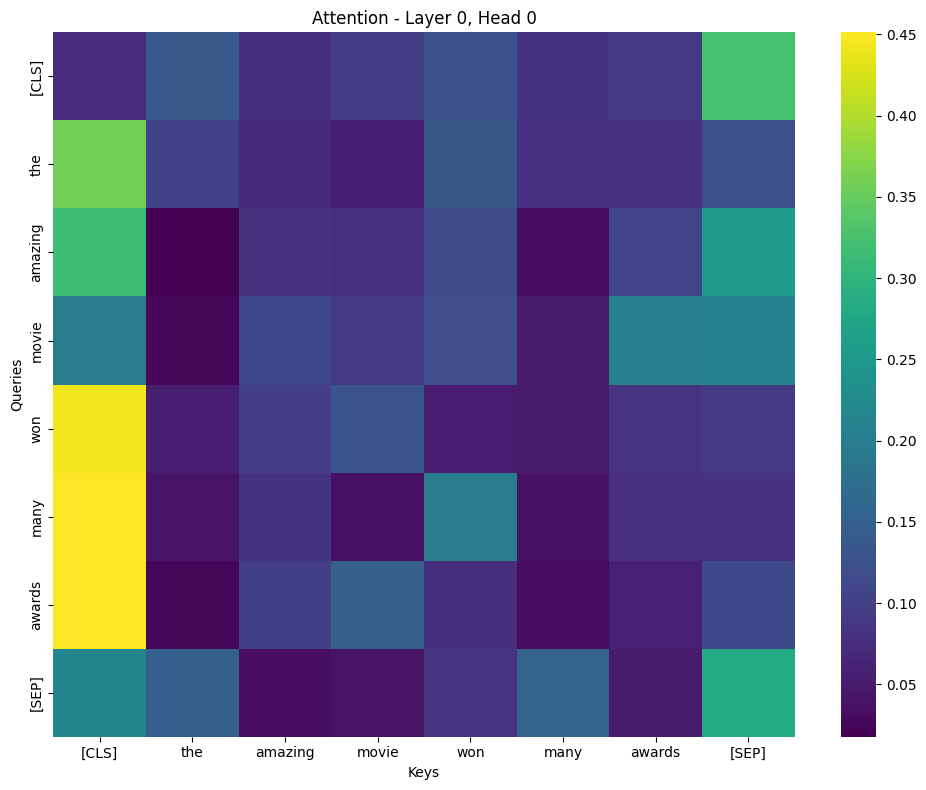

In [ ]:
# Visualization is reusable project logic; the notebook only calls it.
_ = visualize_attention(
    tokens["input_ids"],
    attentions,
    tokenizer,
    layer=0,
    head=0,
    output_path="/tmp/attention_layer0_head0.png",
)

## D3-03/04 — Comparing layers and heads

Сравниваем одни и те же токены. Сначала смотрим, есть ли широкое или локальное распределение, внимание к special tokens (`[CLS]`, `[SEP]`) и повторяющиеся вертикальные полосы. Это наблюдения конкретной модели и фразы, а не универсальные назначения слоёв или голов.

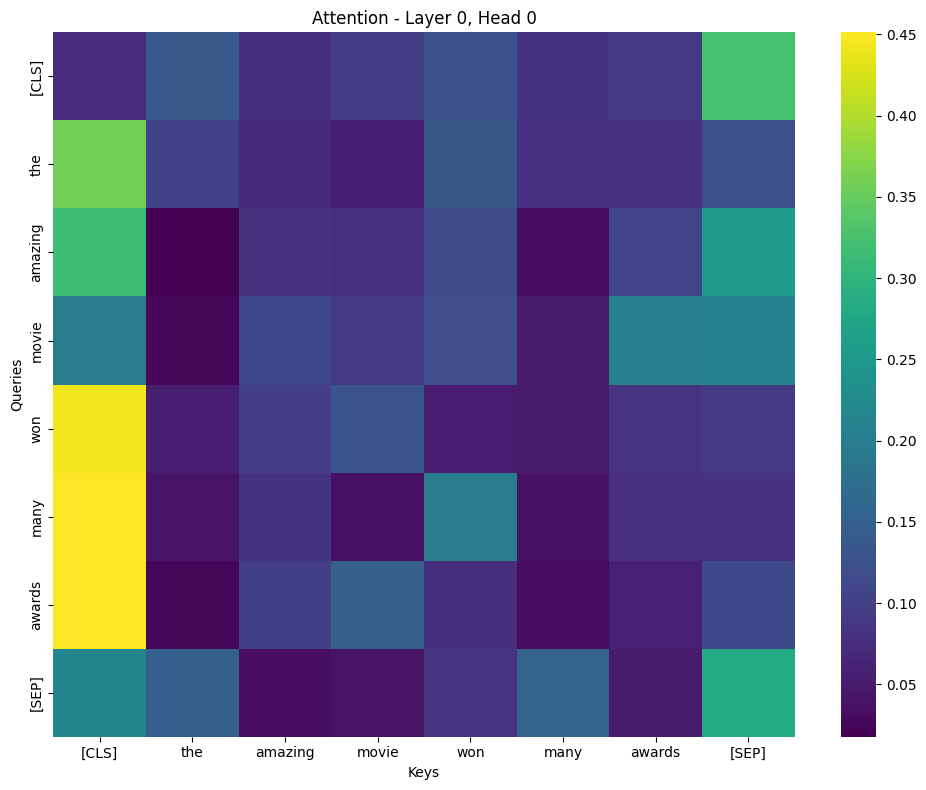

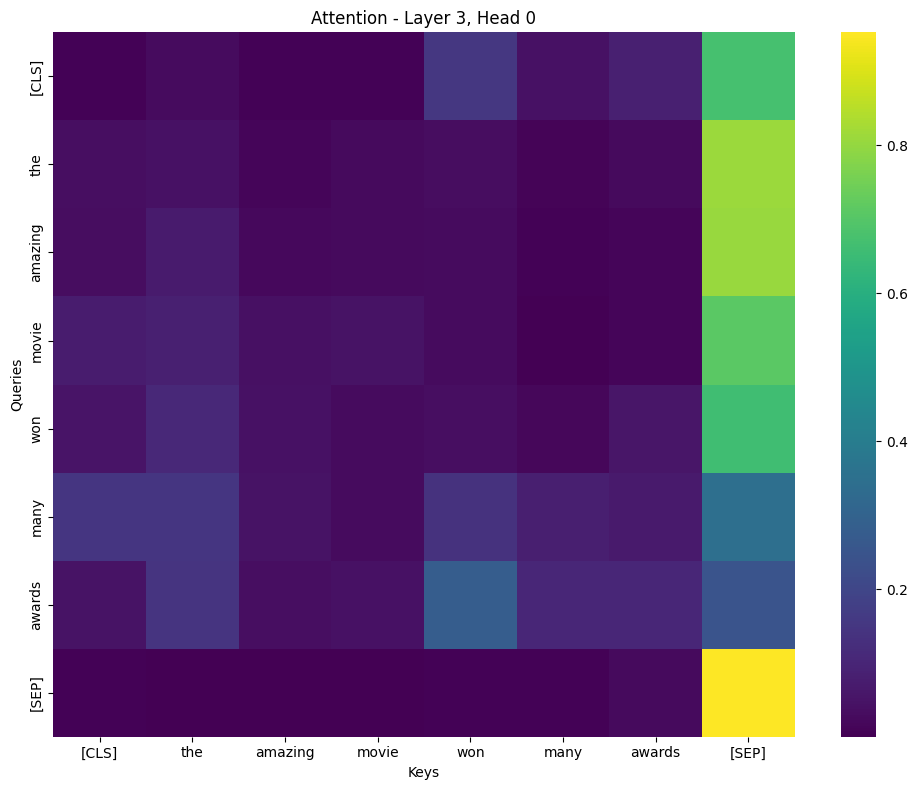

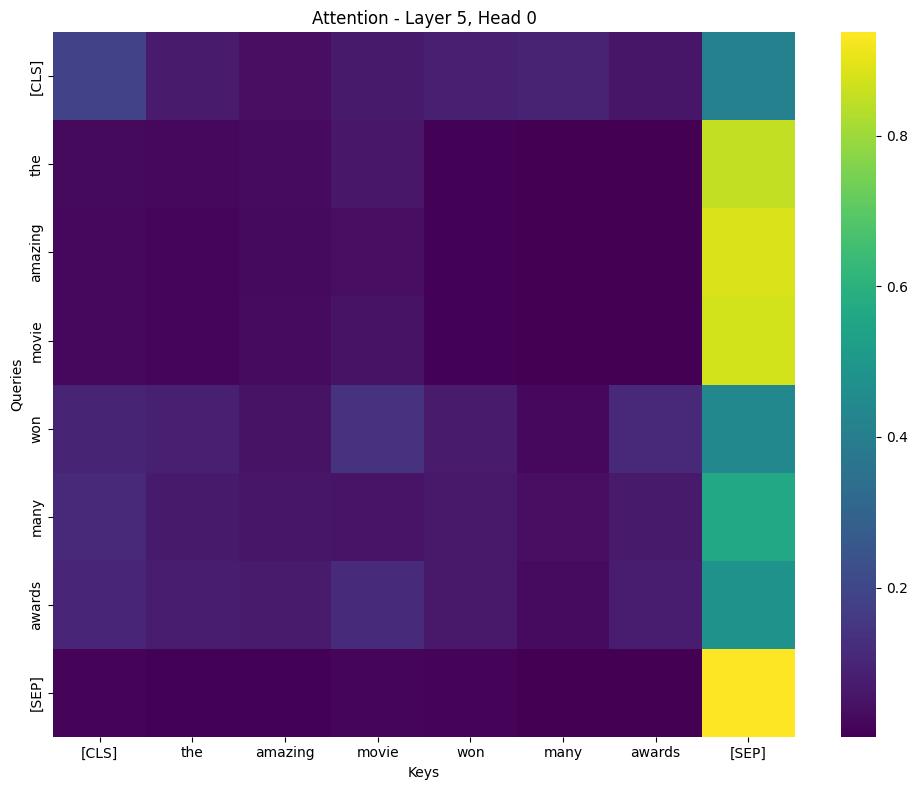

In [ ]:
layer_indices = [0, len(attentions) // 2, len(attentions) - 1]
for layer in layer_indices:
    visualize_attention(
        tokens["input_ids"],
        attentions,
        tokenizer,
        layer=layer,
        head=0,
        output_path=f"/tmp/attention_layer{layer}_head0.png",
    )

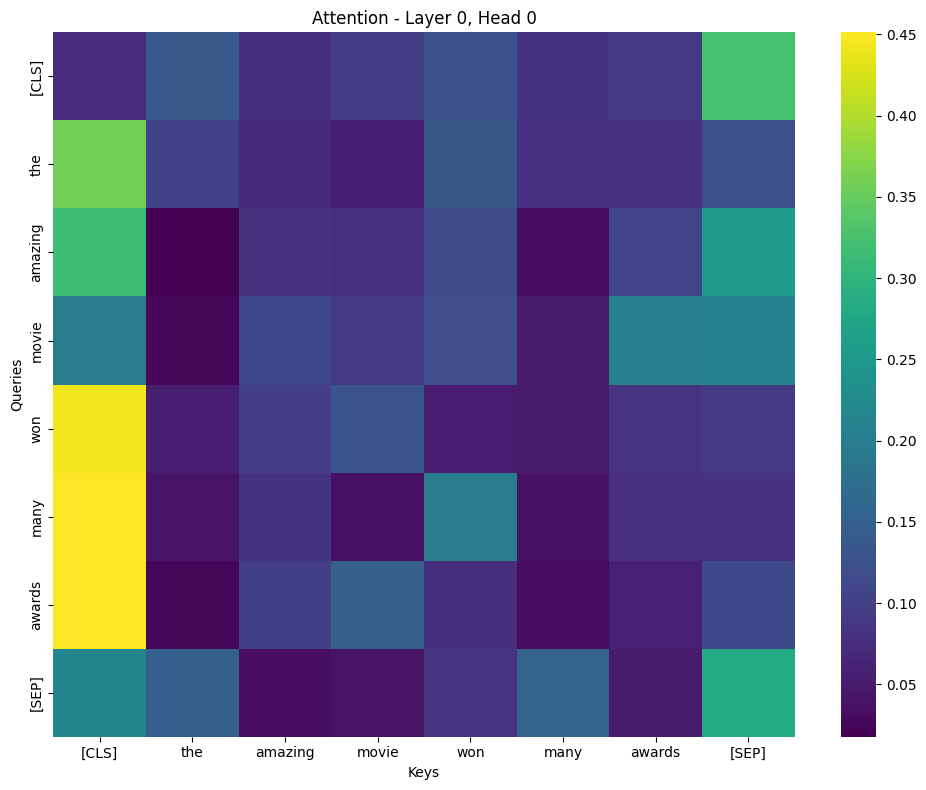

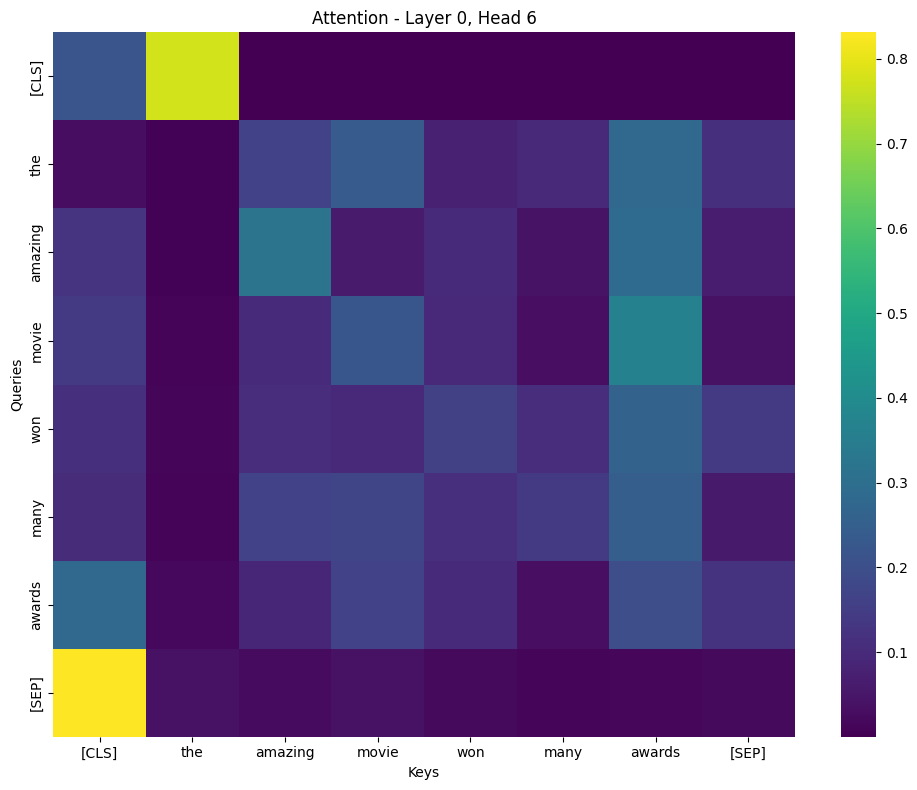

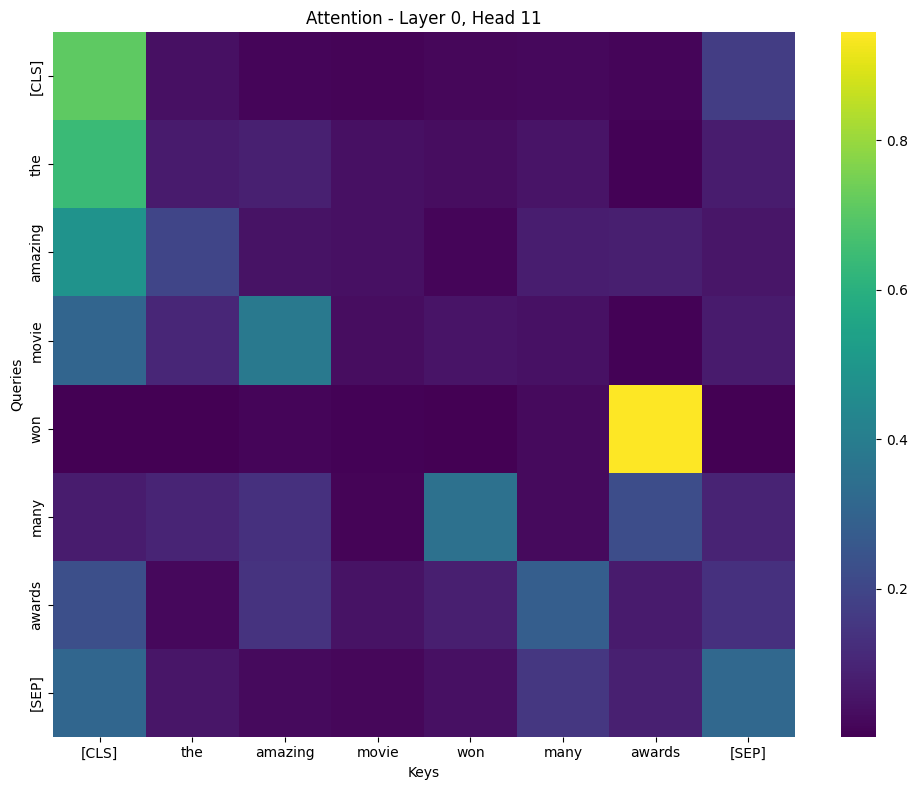

In [ ]:
num_heads = attentions[0].shape[1]
head_indices = [0, num_heads // 2, num_heads - 1]
for head in head_indices:
    visualize_attention(
        tokens["input_ids"],
        attentions,
        tokenizer,
        layer=0,
        head=head,
        output_path=f"/tmp/attention_layer0_head{head}.png",
    )

### Что видно в этом запуске

У `layer=0, head=0` веса сравнительно распределены. У той же головы в средних и последних слоях появляется яркая вертикальная полоса на `[SEP]`: многие query направляют большой вес в special token. Это пример **сфокусированного**, но не обязательно более семантичного attention. В других головах встречаются иные локальные пики; например, отдельная яркая связь может выглядеть осмысленно, но одного предложения недостаточно, чтобы назначить голове устойчивую функцию. Цветовая шкала во всех графиках фиксирована от `0` до `1`, поэтому интенсивность между heatmap можно сравнивать напрямую.

## D3-05 — Inspecting one emotionally loaded token

Ниже мы читаем строку query-токена `terrible`: какие keys получили наибольшие веса. Даже если среди них окажутся эмоциональные слова, base `AutoModel` ещё не выполняет sentiment classification, а один attention-вес не измеряет вклад в предсказание.

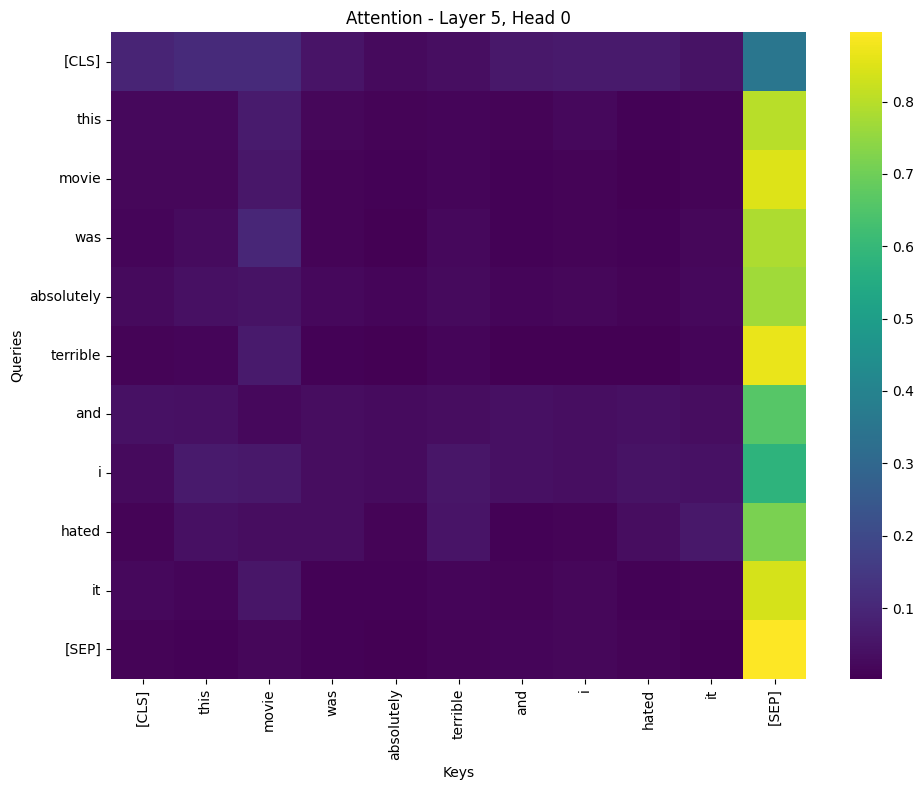

[('[SEP]', 0.8659137487411499),
 ('movie', 0.06143753603100777),
 ('this', 0.015337968245148659),
 ('terrible', 0.013135923072695732)]

In [ ]:
text = "This movie was absolutely terrible and I hated it"
tokens = tokenizer(text, return_tensors="pt")
tokens = {name: tensor.to(device) for name, tensor in tokens.items()}

with torch.no_grad():
    outputs = model(**tokens)

attentions = outputs.attentions
assert attentions is not None
last_layer = len(attentions) - 1
_ = visualize_attention(
    tokens["input_ids"],
    attentions,
    tokenizer,
    layer=last_layer,
    head=0,
    output_path="/tmp/attention_sentiment_last_layer_head0.png",
)

token_ids = tokens["input_ids"][0].detach().cpu().tolist()
token_list = tokenizer.convert_ids_to_tokens(token_ids)
terrible_index = token_list.index("terrible")
terrible_attention = attentions[last_layer][0, 0, terrible_index]
top_indices = torch.topk(terrible_attention, k=min(4, len(token_list))).indices
[(token_list[index], terrible_attention[index].item()) for index in top_indices.tolist()]

## Interpretation checklist

- `attention_mask` — входная маска формы `[batch, sequence]`; она запрещает модели учитывать padding.
- Attention weights — вычисленные моделью матрицы `[batch, heads, query_sequence, key_sequence]`.
- Разные головы действительно могут строить разные паттерны, а разные слои — перерабатывать контекст по-разному. Обязательной понятной человеку закономерности для каждой головы нет.
- Сравнение убедительнее, если паттерн повторяется на нескольких фразах; одна heatmap остаётся исследовательским наблюдением.
- Для утверждения о причине sentiment-предсказания понадобятся обученный classifier и дополнительные методы анализа — это не задача Day 3.